# Core Aspects of MLOps

1. **Data Management**
    - End to end flow of data which have 3 stages
    1. Data Ingestion: load data from files, cloud, dbs, api etc
    2. Data Transformation: perform data cleaning and transformations on this data
    3. Data Storage: store transformed data to cloud or dbs

2. **Modular Coding** Build reusable, testable pipeline components (data ingections, data transformation, model training etc) of ML project using OOPs principles

3. **Versioning** Track every change in code, datasets, and models so you can reproduce any experiment or rollback instantly using tools like github, dvc and mlflow

4. **Experiment tracking**  Log every run's parameters, metrics, and artifacts so we never lose which experiment actually worked and compare the performance

5. **CI/CD** Automate testing and packaging, then deploy anywhere with consistent, containerized environments using tools like github actions, docker etc.

6. **Monitoring** Keep a live pulse on model performance and trigger automated retraining (CT) when metrics degrade using tools like Grafana/Prometheus

7. **Infrastructure management** Provision and scale cloud or on-prem resources efficiently, ensuring cost-effectiveness and reliability.

8. **Governance and Ethics** Enforce data privacy, model fairness, and audit trails so your ML systems are compliant and trustworthy.

# ML Pipelines

- Its not a good idea to write complete code in single file instead create seperate components of each stage
- Create dvc pipeline to execute all sequentially 1 by 1

1. Data Ingestion
2. Data Preprocessing
3. Feature Engineering
4. Model training
5. Model Evaluation

**Initial setup**

1. create a project folder
2. SRC, dvc.yaml, params.yaml
3. git init && dvc init

**Build ML components in src folder**
1. Data Ingestion (load data and perform some basic cleaning and save data)
2. Data Preprocessing (perform processing)
3. Feature Engineering
4. Model Trainer
5. Model evaluation


1. Create dvc.yaml and run dvc repro
2. Integrate params.yaml and re-run ---> Benefits of params.yaml is that we dont need to change anything in code, we can just change the params values from params.yaml and re-produce the results
3. Add exception handling, logging, write functions, type hinting --> write modular code
4. Create project folder using cookiecutter or project template

# Version Control (Code and Data)

- Code versioning & Data versioning
- Code versioning can be done using git on github and for data versioning, we can use dvc
- To integrate code version control:
    1. create venv
    2. add .gitignore file
    3. git init
    4. create github repo or connect existing repo to github
    5. push code
    6. create venv and requirements.txt
    7. dvc init
    8. run dvc repro
- To integrate data versioning using dvc:
    - git cannot store huge data we use dvc
    - for code we have github, for data we can have a data repo : local dbs or cloud dbs
    - dvc will create a **metadata file** of the data file which will have a size of data, hash key etc all details about data
    - we push this metadata file which is very small size along with code on github and data file on data repo
    - when we want to restore our previous code and data file, we can do **git pull** which will pull the code and metadata file of data
    - and **dvc pull** which will pull the correct data file based on metadata file related to that code
    
    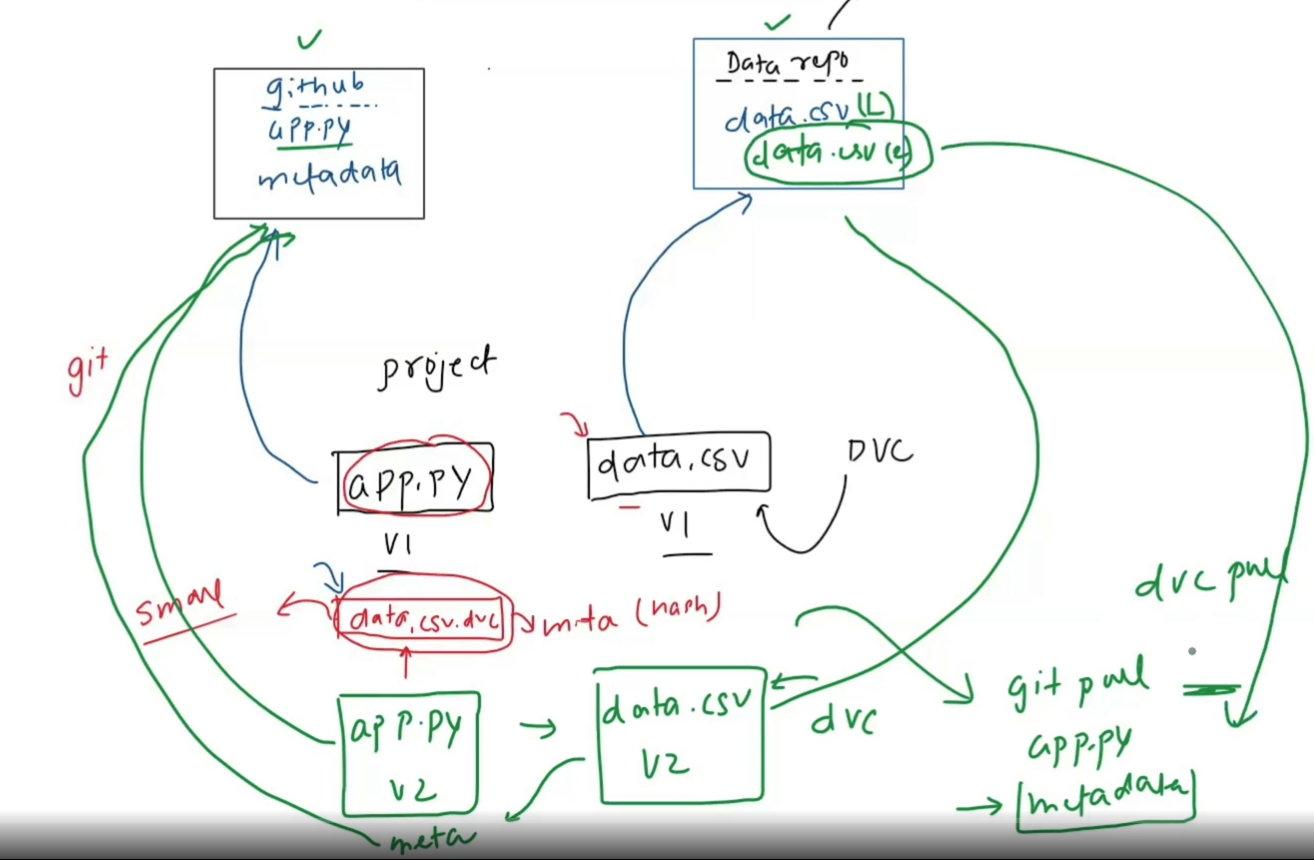

    - **commands**
        1. Add a remote storage
            - dvc remote add -d local C:/Users/iampr/AppData/Local/Temp/dvc-storage
            - dvc remote add -d s3remote s3://your-bucket-name/dvc-store (-d means use this as default)

        2. Push sequence: git add . --> git commit -m "Your commit message here" --> git push --> dvc push
        3. Pull sequence: git pull && dvc pull


    ```
    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>dvc repro --force
    Running stage 'data_ingestion':
    > python src/1_data_ingestion.py
    D:\ML Project\campusx_mlops\ml-pipeline-demo\src\1_data_ingestion.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
    df['sentiment'] = df['sentiment'].replace({'sadness': 0, 'happiness': 1})
    D:\ML Project\campusx_mlops\ml-pipeline-demo\src\1_data_ingestion.py:36: SettingWithCopyWarning:
    A value is trying to be set on a copy of a slice from a DataFrame.
    Try using .loc[row_indexer,col_indexer] = value instead

    See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
    df['sentiment'] = df['sentiment'].replace({'sadness': 0, 'happiness': 1})
    Updating lock file 'dvc.lock'

    Running stage 'data_preprocessing':
    > python src/2_data_preprocessing.py
    [nltk_data] Downloading package stopwords to
    [nltk_data]     C:\Users\iampr\AppData\Roaming\nltk_data...
    [nltk_data]   Package stopwords is already up-to-date!
    [nltk_data] Downloading package wordnet to
    [nltk_data]     C:\Users\iampr\AppData\Roaming\nltk_data...
    [nltk_data]   Package wordnet is already up-to-date!
    Updating lock file 'dvc.lock'

    Running stage 'text_vectorization':
    > python src/3_feature_engineering.py
    Updating lock file 'dvc.lock'

    Running stage 'model_trainer':
    > python src/4_model_trainer.py
    Updating lock file 'dvc.lock'

    Running stage 'model_evaluation':
    > python src/5_model_evaluation.py
    ==================================================
    MODEL EVALUATION PIPELINE
    ==================================================
    ✓ Model loaded from: artifacts/model/logistic_regression_model.pkl
    ✓ Test data loaded: 2976 samples, 25 features

    ==================================================
    EVALUATION RESULTS
    ==================================================
    Accuracy:  0.6307
    Precision: 0.7007
    Recall:    0.4735
    AUC:       0.6962
    ==================================================
    ✓ Metrics saved to: reports/metrics.yaml
    ✓ Experiment info saved to: reports/experiment_info.json

    ✓ Model evaluation completed successfully!
    Updating lock file 'dvc.lock'

    To track the changes with git, run:

            git add dvc.lock

    To enable auto staging, run:

            dvc config core.autostage true
    Use `dvc push` to send your updates to remote storage.

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git status
    On branch main
    Your branch is up to date with 'origin/main'.

    Changes not staged for commit:
    (use "git add <file>..." to update what will be committed)
    (use "git restore <file>..." to discard changes in working directory)
            modified:   .dvc/config
            modified:   .gitignore
            modified:   dvc.lock
            modified:   params.yaml
            modified:   src/3_feature_engineering.py
            modified:   src/__pycache__/mylogging.cpython-310.pyc

    Untracked files:
    (use "git add <file>..." to include in what will be committed)
            requirements.txt

    no changes added to commit (use "git add" and/or "git commit -a")

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git add .

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git commit -m "added s3 remote"
    [main e103923] added s3 remote
    7 files changed, 62 insertions(+), 48 deletions(-)
    create mode 100644 requirements.txt

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git push && dvc push
    Enumerating objects: 22, done.
    Counting objects: 100% (22/22), done.
    Delta compression using up to 4 threads
    Compressing objects: 100% (11/11), done.
    Writing objects: 100% (12/12), 1.52 KiB | 259.00 KiB/s, done.
    Total 12 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
    remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
    To https://github.com/iamprashantjain/ml-pipeline-demo-v1.git
    4229591..e103923  main -> main
    Collecting                                                                                                                                                                                                        |10.0 [00:00,  213entry/s]
    Pushing
    10 files pushed
    ```

# Experiment Tracking

- **Comprehensive logging of all experimental metadata throughout the model development lifecycle, including:**

    1. Hyperparameters – Learning rates, batch sizes, optimizer configurations, regularization parameters, and model architecture settings
    2. Datasets – Data sources, versioning, preprocessing steps, augmentation techniques, and train/validation/test splits
    3. Code Versions – Git commit hashes, branch names, repository URLs, and any uncommitted changes or patches
    4. Environment – Operating system, Python versions, dependency libraries (with exact versions), CUDA setups, and hardware specifications
    5. Performance Metrics – Training/validation losses, accuracy, precision, recall, F1-score, AUC-ROC, inference latency, and model size
    6. Artifacts – Model weights, visualization outputs (confusion matrices, feature importance plots), sample predictions, and training logs

- **benefits:**
    1. Reproducibility – Recreate any experiment precisely, eliminating the "works on my machine" problem and ensuring consistent results across team members and time
    2. Comparative Analysis – Visualize and compare multiple runs side-by-side to identify which configurations yield optimal performance
    3. Team Collaboration – Enable seamless knowledge sharing, prevent redundant work, and allow team members to build upon each other's experiments
    4. Actionable Insights – Uncover patterns and correlations (e.g., "batch size 64 consistently outperforms 256"), leading to more informed modeling decisions
    5. Audit & Compliance – Maintain transparent records for regulatory requirements (GDPR, HIPAA, financial audits) and document which model versions were deployed and why

- **Tools**
    1. mlflow (experiment tracking & model registry)
    2. weights & biases
    3. neptune
    4. comet
    5. dvc

## MLFlow

**ML Workflow**

1. Conduct systematic experiments with MLflow to identify the best model and hyperparameters through baseline modeling, algorithm selection, and hyperparameter tuning.
2. Deploy mlflow experiments to Dagshub or AWS so that everybody can see it
3. Transform the winning experiment into a reproducible DVC pipeline with versioned data, parameterized stages, and tracked metrics for one-command reproducibility (dvc repro).
4. Automate model validation and registration by running DVC pipeline on code changes, validating performance thresholds, and pushing approved models to MLflow Model Registry.
5. Deploy registered models to production using AWS SageMaker endpoints, Lambda functions, or S3 with blue-green deployment and automatic rollback capabilities.
6. Monitor production models for data/concept drift, trigger automated retraining when performance degrades, validate new models against the champion, and seamlessly promote superior models to production.


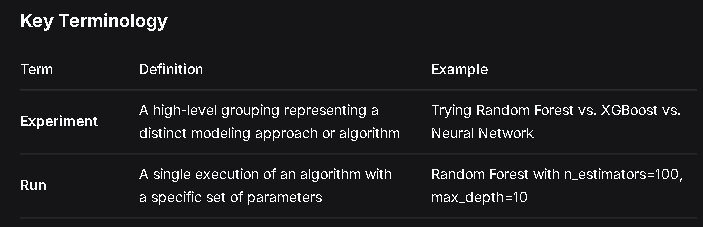

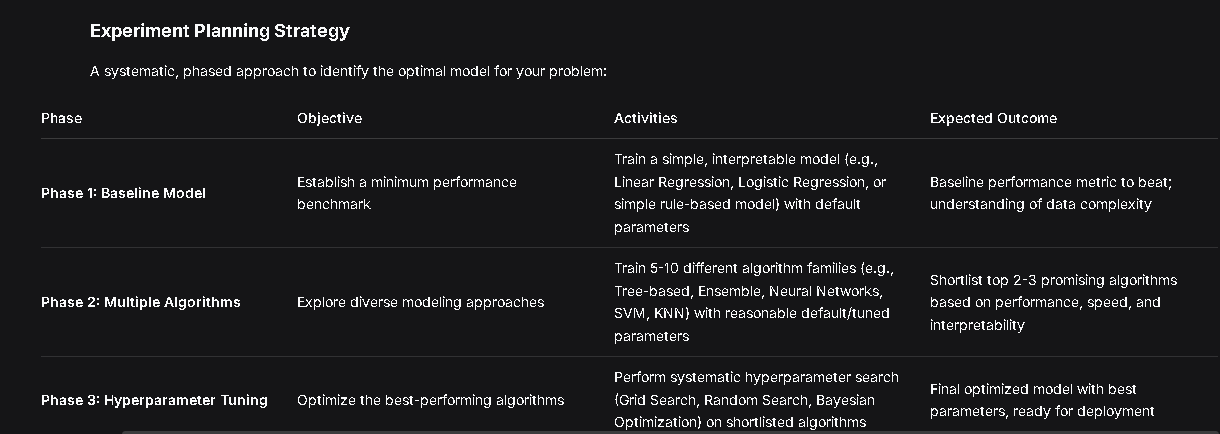

- when we run mlflow it will create a folder called "mlruns"
- this file will meta details about all the experiments

- **Sample Code**

    ```
    import mlflow
    import mlflow.sklearn
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set/create new experiment
    mlflow.set_tracking_uri("https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow")

    os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME", "iamprashantjain")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD", "")
    
    mlflow.set_experiment("base_model")

    max_depth = 5
    n_estimators = 100

    with mlflow.start_run(run_name='prashant_exp1') as run:
        
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Log params
        mlflow.log_param('n_estimators', n_estimators)
        mlflow.log_param('max_depth', max_depth)
        
        # Log metrics
        mlflow.log_metric('accuracy', accuracy)
        
        # Log artifacts
        # Create confusion matrix plot
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.savefig('confusion_matrix.png')
        mlflow.log_artifact('confusion_matrix.png')
        plt.close()

        #log current code file
        mlflow.log_artifact(__file__)
        
        # Log model
        mlflow.sklearn.log_model(model, "random_forest_model")

        #set tags
        mlflow.set_tag('author','prashantjain')
        mlflow.set_tag('model','RandomForestClassifier')

        #log dataset
        #merging train & test data
        train_df = X_train
        train_df['variety'] = y_train

        test_df = X_test
        test_df['variety'] = y_test

        #converting dataset into mlflow acceptable format
        train_df = mlflow.data.from_pandas(train_df)
        test_df = mlflow.data.from_pandas(test_df)

        mlflow.log_input(train_df, context='training')
        mlflow.log_input(test_df, context='validation')
    ```

- We can also use mlflow.auto_log() to be defined at the top to log everything automatically
- It will log:
    1. metrics
    2. parametres
    3. model signature
    4. artifacts
    5. dataset

- **What can mlflow track**

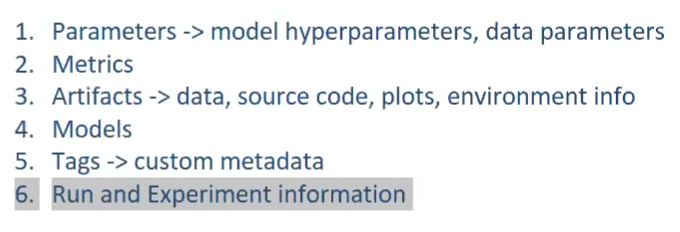

- **To perform hyper-parameter tuning with MLflow** using nested runs, you'll create a parent run for the overall tuning process and child runs for each parameter combination trial. The nested=True parameter in mlflow.start_run() is the key to establishing this hierarchical relationship

    ```
    import mlflow
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.datasets import make_classification
    from sklearn.model_selection import cross_val_score
    import numpy as np

    # Generate data
    X, y = make_classification(n_samples=200, n_features=10, random_state=42)

    # Hyperparameters to test
    params_grid = [
        {"n_estimators": 50, "max_depth": 3},
        {"n_estimators": 100, "max_depth": 5},
        {"n_estimators": 150, "max_depth": 7},
    ]

    # Parent run
    with mlflow.start_run(run_name="tuning_parent") as parent:
        best_score = 0
        best_params = None
        
        # Child runs (nested)
        for params in params_grid:
            with mlflow.start_run(nested=True, run_name=f"trial_{params}") as child:
                # Log params for this trial
                mlflow.log_params(params)
                
                # Train and evaluate
                model = RandomForestClassifier(**params, random_state=42)
                score = np.mean(cross_val_score(model, X, y, cv=3))
                
                # Log metric
                mlflow.log_metric("cv_score", score)
                
                # Track best
                if score > best_score:
                    best_score = score
                    best_params = params
        
        # Log best to parent
        mlflow.log_metric("best_cv_score", best_score)
        mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
        
        print(f"Best: {best_params} with score {best_score:.3f}")
    ```

# Model Registry

- A Model Registry is a centralized repository that stores, versions, and manages ML models throughout their lifecycle. Just like GitHub tracks code changes, a model registry tracks:

    1. Model versions (v1, v2, v3)
    2. Model metadata (parameters, metrics, training data)
    3. Model artifacts (serialized model files)
    4. Model lineage (which code/data produced this model)
    5. Model stages (Staging, Production, Archived)

- Model Registry is indeed the crucial bridge between Data Science (development) and Ops (production) in the MLOps lifecycle.
- All machine learning development happens here - experimentation, training, tuning, and evaluation. This ends when the model is pushed to production in model registry.
- After the model is in the registry, Ops takes over - deploying to production servers, monitoring performance, and maintaining the live system.

- **Stages of model**
1. Development or None: create and refine the model to get the best performance
2. Staging: Transition model from development to staging, perform UAT tests
3. Production: Transition model from development to production, now Ops team will deploy this model in production, Monitoring is also established to Monitor model performance
4. Archive/Retire: When model performance degrades, we will retire this model and deploy new model following all above steps


```
from mlflow.tracking import MlflowClient
import mlflow

client = MlflowClient()

#run id of the run where model was logged
run_id = "6707d37f29bf4af994be9515f6c014f8"

#model_path
model_path = "mlflow-artifacts:/5ab3b8ab878949c7b7c5cc0e1419a7e0/models/m-b57e97e335a94bf7ad745ec9d7008848/artifacts/model.pkl"

#model_uri
model_uri = f"runs:/{run_id}/{model_path}


#register model
model_name = "model"
result = mlflow.register_model(model_uri, model_name)


#description
client.update_model_version(
    name = model_name,
    version = result.version,
    description = "this is a test model"
)

client.set_model_version_tag(
    name = model_name,
    version = result.version,
    keys = "experiment",
    value = "twitter emotions"
)
```

# CI/CD Pipeline

- Generate requirements.txt
- Add **ci.yaml** inside .github\workflows
- Add **DAGSHUB_TOKEN** in secret variables in github repo
- CI Steps:
    1. setup running dvc pipeline on git push
    2. tests (model test & performance)
    3. if test success: promote model to production
    4. flask/fast api testing
    5. dockerize flask app & push to ecr
    6. deploy docker image on ecr to aws

# Docker

- Docker is a platform that enables developers to build, share, and run applications inside containers - lightweight, portable environments that package everything needed to run the software consistently.

**Understanding Docker through an Analogy: Maggi Noodles**
  - A pack of Maggi noodles has **two main components**: noodles and masala (spice mix)
  - If the masala recipe varies, the same noodles will taste **different** depending on who prepares it
  - The taste becomes **inconsistent** and **unpredictable** across different kitchens
  - The Maggi manufacturer creates a **standardized "masala container"** - a pre-measured, sealed spice packet
  - This ensures that **no matter where or who cooks it**, the Maggi will taste **exactly the same** every time

**The Parallel in Software Development**
  - Software faces a similar challenge - it runs differently across environments
  - Variations in:
    - Operating systems
    - Library versions
    - Dependencies
    - Configuration settings
  - An application that works perfectly on a developer's machine may **fail** on another system
  - This leads to the infamous *"it works on my machine"* problem

- **The Solution (Containerization):**
  - Docker packages the **application** along with its:
    - Environment
    - Dependencies
    - Configuration files
    - System tools
  - This package is called a **Docker Image**
  - The image can be **run anywhere** - on any machine, cloud, or operating system
  - It will behave **identically** regardless of where it's deployed

**Key Benefits**

- **Consistency**: Same behavior across development, testing, and production
- **Portability**: Run on any system without compatibility issues
- **Isolation**: Each application runs in its own environment, avoiding conflicts
- **Reproducibility**: Others can replicate your exact setup with a single command

docker build --no-cache -t emotion1 . && docker run -p 8888:5000 -e DAGSHUB_TOKEN="YOUR_DAGSHUB_TOKEN" emotion1

## How to reduce docker image size

1. choose minimal base image: slim or alpine
2. use multi stage build
3. minimize layers
4. use .dockerignore file
5. minimize python package (use --no-cache-dir)
6. remove temp files
    - RUN apt-get clean && rm -rf /var/lib/apt/lists/* /tmp/* /var/tmp/*

# End to End ML Workflow

| Stage | What to do | Tools |
|-------|------------|-------|
| We have a ML Problem | - | - |
| Data Wrangling | Scraping data or extracting data from databases or APIs | Python & Pandas |
| Data Assessment | Assess complete data to find out what to clean and strategize | Python & Pandas |
| Data Cleaning | Clean data based on above strategy | Python & Pandas |
| EDA | Explore every column including target column and multiple columns to find relations and effect on target column | Python & Pandas |
| Another round of Data Cleaning | Clean data based on above strategy | Python & Pandas |
| Feature Engineering | Create more features if possible as understood during EDA | Python & Pandas |
| Experimentation | Perform experiments to find baseline model, best model and best hyper parameters | MLflow |
| ML Pipeline | Create reproducible ML pipeline & log model in model evaluation stage to MLflow experiment tracking | DVC |
| Register Model | Push experiment tracking model to model_registry in STAGING stage | MLflow Model Registry |
| Model_Serving | Create API around model so that it can be integrated on website and users can actually use it | FastAPI & Pydantic |
| CI | 1. Run DVC pipeline on GitHub Runner<br>2. Generate the model, log & push model to staging in model registry - so that any change in code, on git push, it should trigger DVC pipeline, and new model will be added to model_registry as staging (so that testing perform)<br>3. Test model:<br>&nbsp;&nbsp;&nbsp;- Model loading<br>&nbsp;&nbsp;&nbsp;- Model signature<br>&nbsp;&nbsp;&nbsp;- Model performance testing (like threshold > 90% or compare with existing production model)<br>4. Promote model to production<br>5. Flask app testing<br>6. Dockerize Flask app & push to ECR<br>7. Deploy docker image to AWS | github actions, docker, aws |
| CD | Once docker image is in AWS ECR, We can pull that image from ECR and deploy it to EC2 or ECS | aws ec2, codedeploy, ecs |

# EC2 Deployment

**Manual**

1. setup ec2 on aws
2. connect
3. run below commands:
    - sudo apt-get update
    - sudo apt-get install -y docker.io
    - sudo systemctl start docker
    - sudo systemctl enable docker
    - sudo apt-get update
    - sudo apt-get install -y unzip curl
    - curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
    - unzip awscliv2.zip
    - sudo ./aws/install
    - sudo usermod -aG docker ubuntu

    - **1 lline command of above** : sudo apt-get update && sudo apt-get install -y docker.io && sudo systemctl start docker && sudo systemctl enable docker && sudo apt-get update && sudo apt-get install -y unzip curl && curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip" && unzip awscliv2.zip && sudo ./aws/install && sudo usermod -aG docker ubuntu

    - aws configure
    - **close and reconnect**
    - aws ecr get-login-password --region ap-south-1 | docker login --username AWS --password-stdin 739275446561.dkr.ecr.ap-south-1.amazonaws.com
    - docker pull 739275446561.dkr.ecr.ap-south-1.amazonaws.com/prashant-ecr:latest 
    - docker run -d -p 80:5000 -e DAGSHUB_TOKEN=7bed6b5be2021b1a4eaae221787bcb048ab2bcfd --name my-flask-app 739275446561.dkr.ecr.ap-south-1.amazonaws.com/prashant-ecr:latest

4. Add security groups:
    - instances -> security -> security groups -> edit inbound rules -> add http at port 80 & allow 0.0.0.0/0 ip address -> save rules
    - security group should have 2 rules: ssh & http

5. copy public dns link, remove s from https & run on chrome    

**Autmated: via CI**

1. create ec2 machine
2. setup ec2 machine:
    - sudo apt-get update
    - sudo apt-get install -y docker.io
    - sudo systemctl start docker
    - sudo systemctl enable docker
    - sudo apt-get update
    - sudo apt-get install -y unzip curl
    - curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
    - unzip awscliv2.zip
    - sudo ./aws/install
    - sudo usermod -aG docker ubuntu
    - exit
    - check docker version

3. update security group inbound rules

3. update github secret:
    - ec2_host: public dns (ec2-13-201-226-0.ap-south-1.compute.amazonaws.com) #This is how ci will know where to deploy
    - ec2_user: ubuntu
    - ec2_ssh_key: pem file content

4. update ci.yaml
5. push to git and check public dns url with http

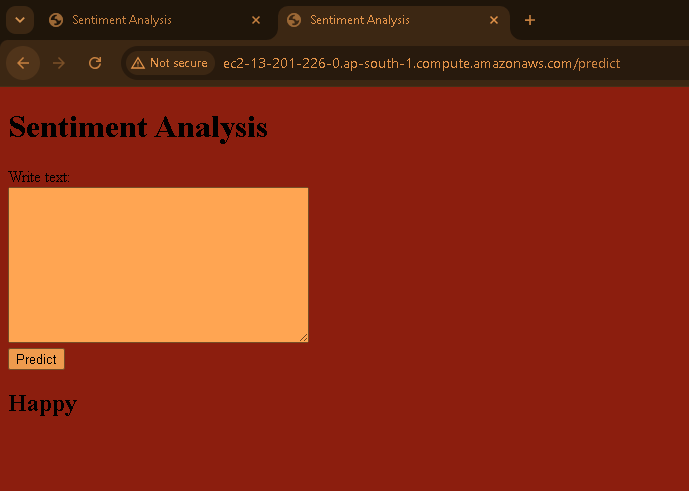

## **Issues with above EC2 deployment**

1. Scalability
    - Current Setup: Single server with one container, prone to failure under high traffic.
    - Scalability Approaches:
        1. Vertical Scaling: Upgrade existing hardware (CPU, RAM, cache).
        2. Horizontal Scaling: Add more servers to distribute load.
    - Preferred Method: Horizontal scaling is the standard practice for distributed systems.
    - For horizontal scaling, we need to manually setup EC2 machines, install, pull & run docker but if we have to do it for 100 of servers, It will be challenging to do it manually
2. Manually Starting and Stopping
    - we have to manually start or stop the servers as load increases
3. Traffic routing
    - We're doing this to distribute the load and handle traffic but there is no system which can distribute the load among more then 1 servers as of now
4. Rigid Setup
    - Fix 2 or 100 servers, not binded to traffic - whether we have huge traffic or not, 100 servers are live
5. Code Updating
    - we have to manually update the code on all servers
6. Pottential downtime
    - There will be some downtime while code is being updated
7. NO centralized monitoring
    - we have to individually check each servers whether they are live or dead
8. Security Management
    -  we have to individually manage security
9. Fault Tolerance
    - there is no fault tolerance system, we have to check manaually whether server is live or dead and spin new server if dead
10. CI/CD complexity
    - CI/CD is for 1 server but doing the same for 100 servers will be complex

## Solution

- **Deploy using AWS CodeDeploy with Auto Scaling Groups and Load Balancer integration for high availability and zero-downtime rolling updates**

**Steps**

1. create a new IAM role with all access permissions (EC2, ECR, S3)

2. create new launch template: 
    - aws > ec2 > launch template
    - check auto scaling guidance
    - quick start > ubuntu > instance: t2 micro > login pair > security group > advance detail: select iam profile
    - add user data script
    - create launch template

3. create auto scaling group using above launch template
    - select 2 availability zones
    - attach new load balancer
    - application + internet facing
    - creat new target group
    - turn on elastic load balancing health checks
    - enable monitoring
    - add desired capccity
    - target tracking scaling policy - avg cpu utilization
    - create auto scaling group
4. check if codedeploy agent is running on each ec2 server: sudo service codedeploy-agent status
    - **if not running then do it manually:** #!/bin/bash
sudo apt-get update -y && sudo apt-get install ruby-full wget gdebi-core -y && cd /home/ubuntu && rm -f install install.* && wget https://aws-codedeploy-ap-south-1.s3.ap-south-1.amazonaws.com/latestv2/install && chmod +x ./install && sudo ./install auto && sudo systemctl enable codedeploy-agent && sudo systemctl start codedeploy-agent

5. create new codedeloy application
    - codedeploy > applications > compute platform: ec2
    - create deployment group > select iam role > select deployment type > select asg > deployment setting > select load balancer > create deployment group

6. add 3 files in the project folder and push to github
    1. appspec.yml
    2. deploy\scripts\install_dependencies.sh
    3. deploy\scripts\start_docker.sh


**-- AWS Setup completed, Now: --**

7. update cicd to get the files from github
8. push the code and deployment will trigger


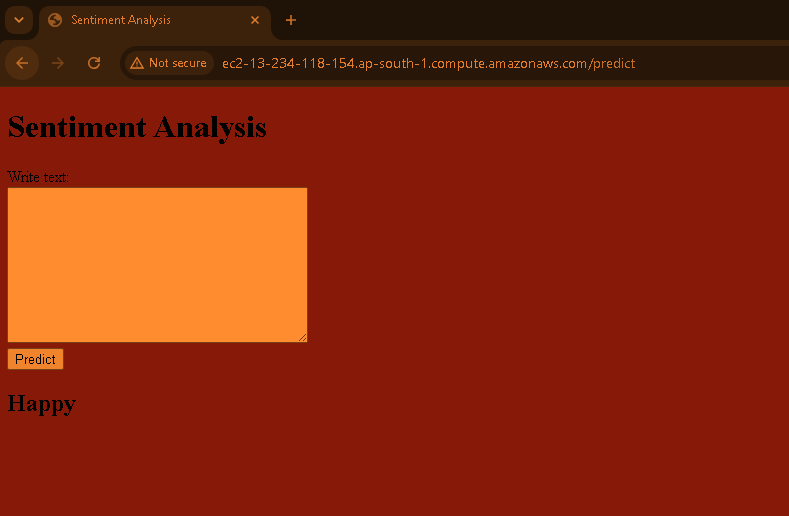

# Kubernetes

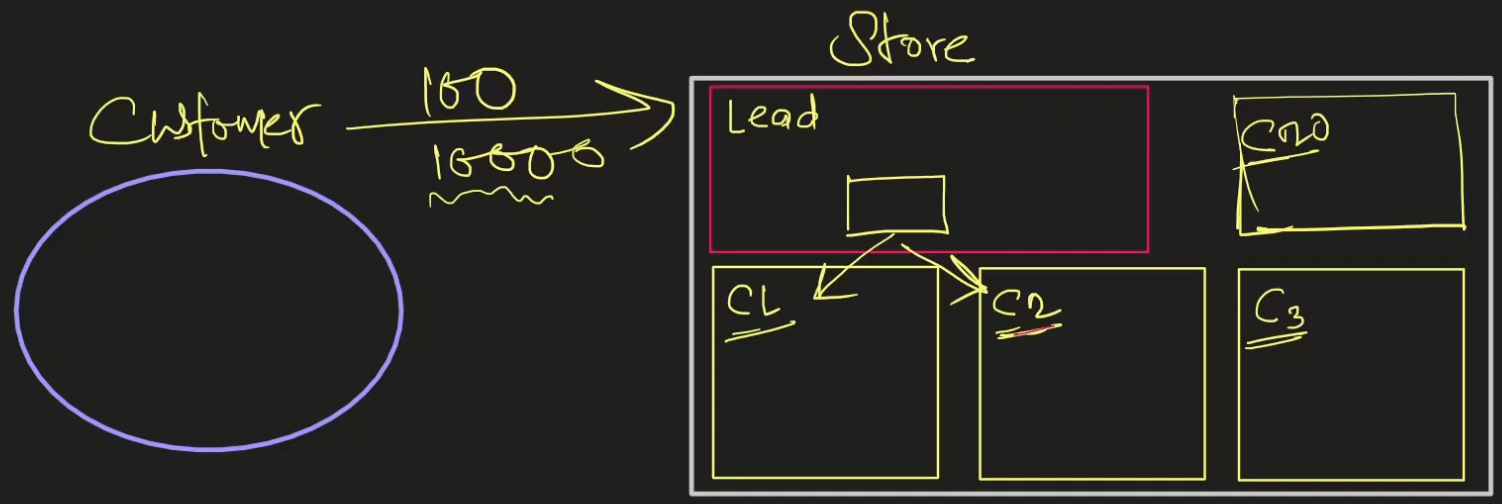

- Let's assume we own a restaurant, Initially we are managing it completely on our own
- Our restaurant got famous and customers increased so we hired more chefs and distributed the work among them
- We started receiving even more orders, we hired more chefs and distributed the workload
- Let's imagine the same scenario in terms of machine learning, Initially we were processing the whole ML workflow on a single server (Monolithic architecture) but as our data increased, processing and model development started taking more time so we added more servers and now each component of ML workflow is being processed on individual server
- That's the power of **Distributed Computing**

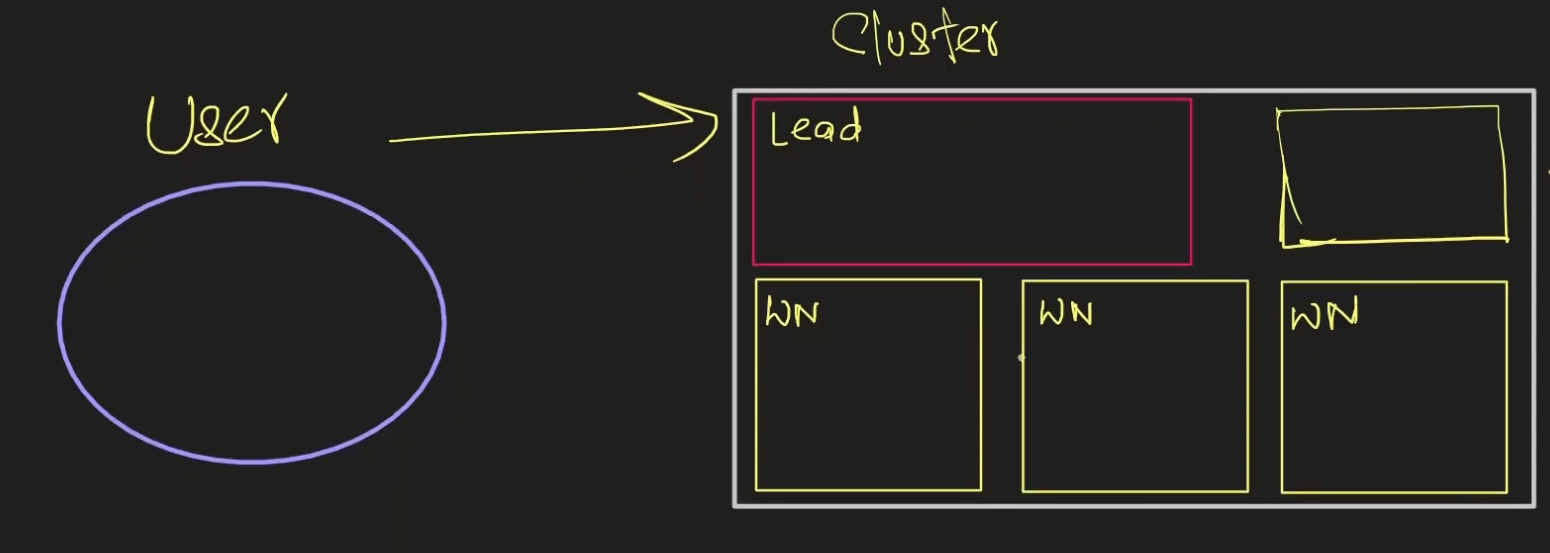

- Running everything on single server is called Monolithic Architecture, But load has increased only on processing component, we need to increase the configuration of that component only but since we are running everything on single server, we have to increase complete configuration.
- We can run every component individually on 1 server and if any component is not able to handle it alone then we can distribute it to more servers for that component only
- This architecture where each service or component is running individually on server is called **Microservice architecture**

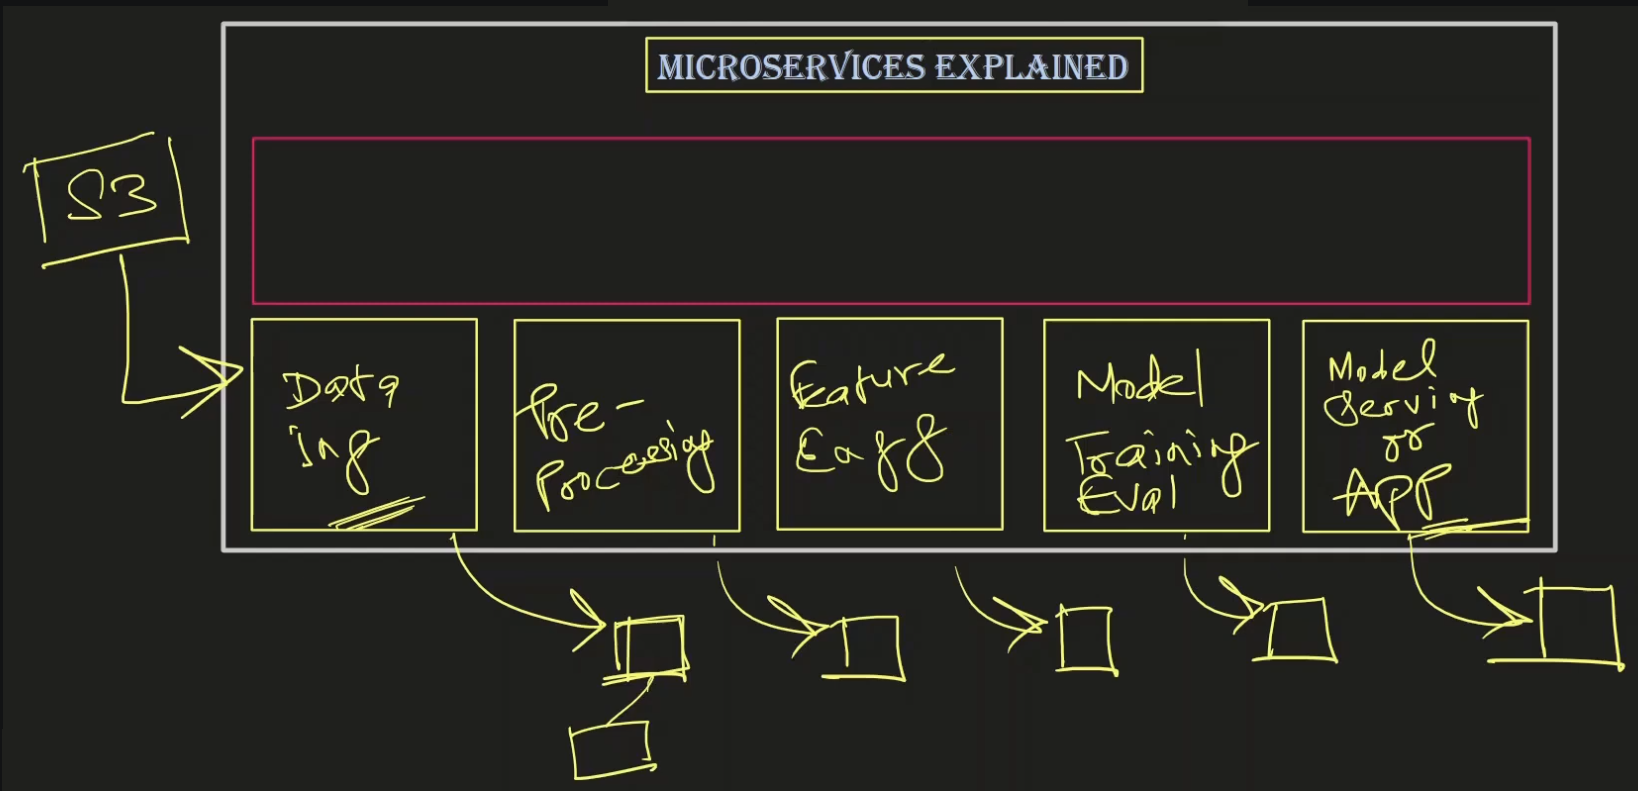

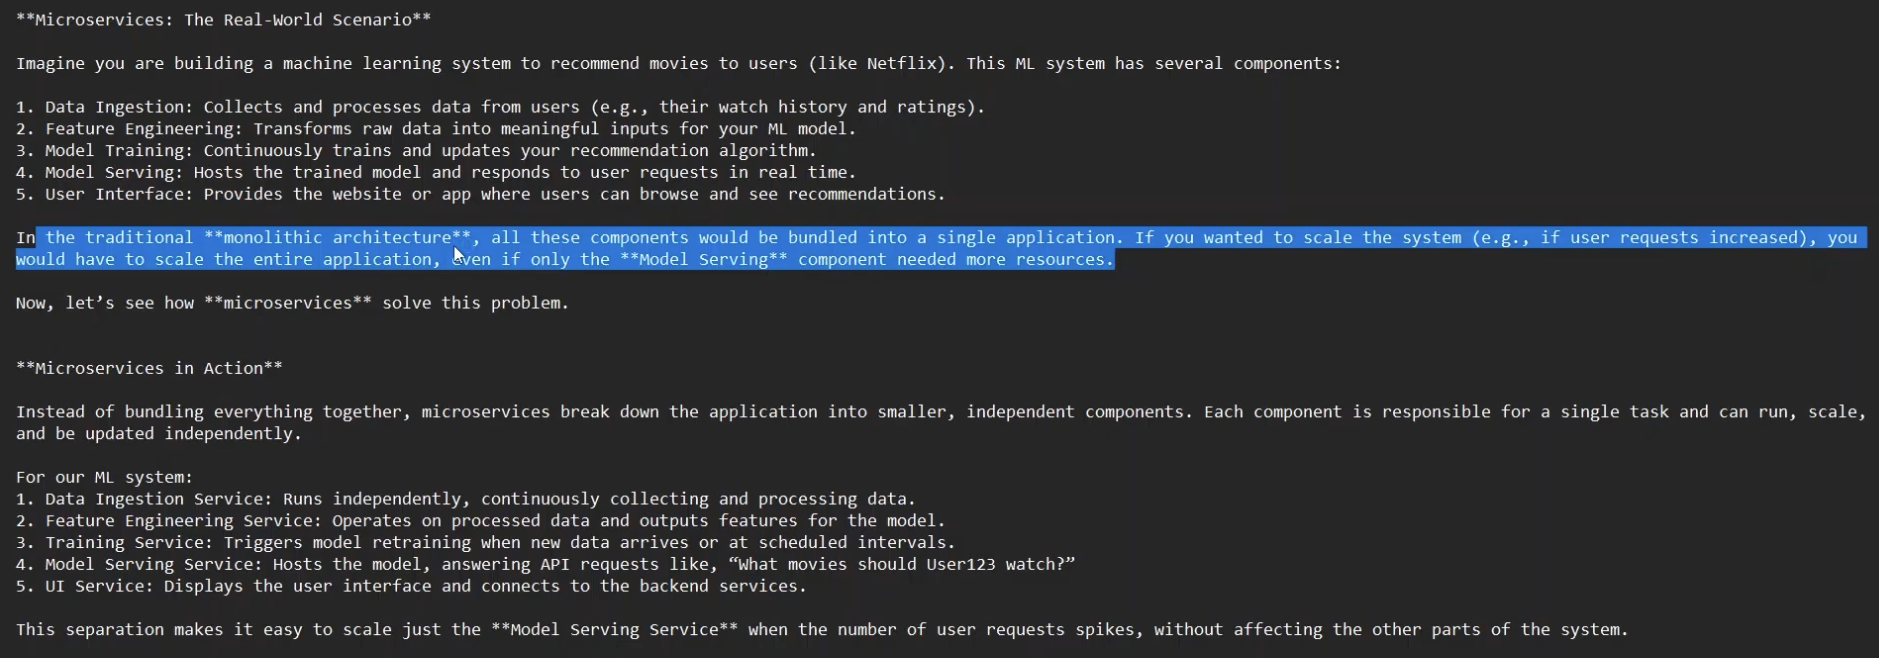

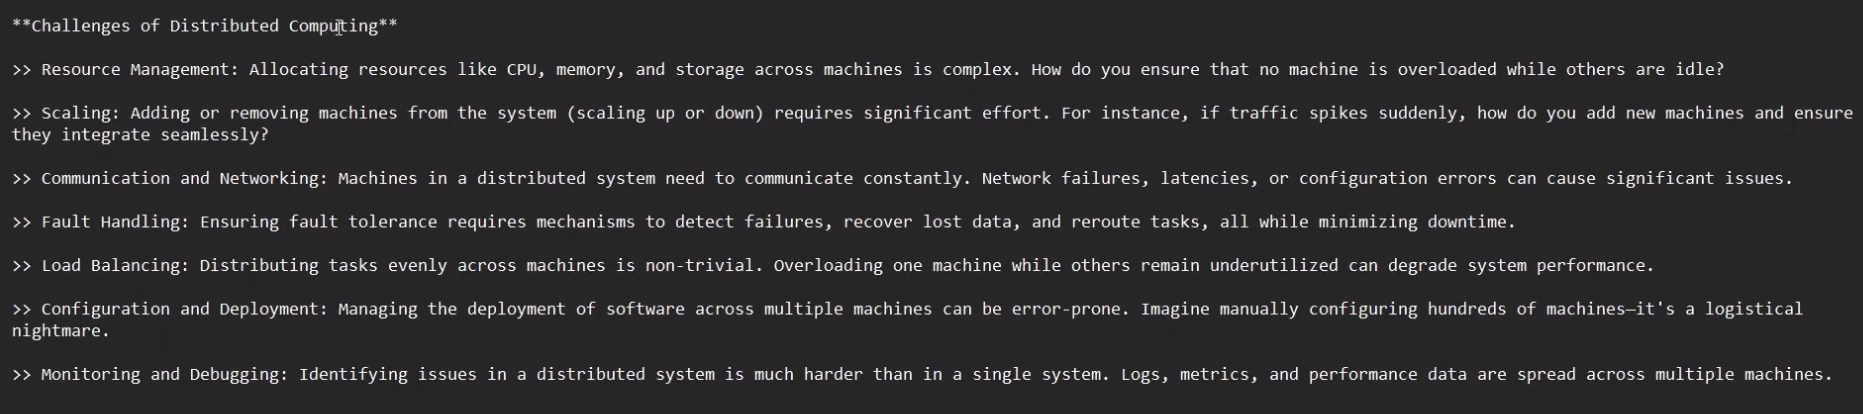

## Kubernetes Internals

Master Node (Control Plane): The master node is the brain of the Kubernetes cluster. It oversees the system, manages workloads, and ensures everything runs as expected. Think of it as the manager in a factory that delegates tasks and monitors operations.


Resource Manager: The resource manager in Kubernetes ensures that cluster resources like CPU, memory, and storage are allocated efficiently. It’s like a warehouse manager who ensures that raw materials (resources) are distributed to the right production lines (nodes).


API Server (For user comm): Users interact with Kubernetes through the API Server. It’s like the receptionist at an office—you send requests (like deploying an app), and the API Server routes them to the appropriate components in the cluster.


Database (etcd): `etcd` is Kubernetes' central database where all cluster data is stored, including the current state of the system and desired configurations. Imagine it as a library catalog—every time you check out or return a book, the catalog is updated to reflect the changes.


Worker Node: Worker nodes are the muscle of the cluster. They run your applications and handle the tasks assigned by the master node. Think of them as factory workers who execute tasks given by the manager (master node).


Kubelet: The kubelet is an agent running on each worker node that ensures containers (your applications) are running as expected. It’s like a shift supervisor in a factory who ensures each machine is operating correctly.


Kube-Proxy: The kube-proxy manages network traffic for pods, ensuring they can communicate with each other and the outside world. It’s like a traffic cop at a busy intersection, directing cars (data packets) to the right destinations.


Pods: A pod is the smallest deployable unit in Kubernetes and typically wraps one or more containers. Think of it as a container ship holding one or more goods (containers) and transporting them across a logistics network.


SharedDB (Volumes): Volumes are shared storage spaces in Kubernetes that allow pods to save and share data. It’s like a shared locker room where workers (pods) can access tools or leave notes for each other.


Kube-Manifest (YAML): Kube manifests are configuration files written in YAML that define what you want Kubernetes to do, such as deploying an app or creating a service. Think of it as the blueprint for building a house—Kubernetes reads it to know exactly what to construct.


Service: A service in Kubernetes provides a stable network endpoint for accessing a set of pods. Even if the pods are replaced or moved, the service ensures they can still be reached. It’s like a restaurant hotline—no matter who answers the phone (which server pod), your order is taken.


Namespace: Namespaces are virtual clusters within a Kubernetes cluster that help organize and isolate resources. It’s like different departments in a large office building—HR, Sales, and IT each work in separate areas but share the same infrastructure.


Scheduler: Decides which worker node will run a new pod based on resource availability. It's like a dispatcher allocating tasks to the most available worker.


ReplicaSets: Ensure that a specified number of identical pods are always running. It’s like a backup generator ensuring there’s always power even if one generator fails.

## Kubernetes Practical

1. create a simple flask app (ideally it will be a ml app) and test locally
2. create docker image of this app (create dockerfile)
    - docker build -t kubernetes-test-app:latest .
    - docker images
    - docker run -p 5000:5000 kubernetes-test-app:latest

**Understand how to push this docker image to kubernetes and how deployment happens in pods**

3. create deployment.yaml (This is kube manifest file where we define all configuration and settings of kubernetes)
4. use **minikube** service to create a kubernetes cluster in windows
    - install minikube: https://minikube.sigs.k8s.io/docs/start/?arch=%2Fwindows%2Fx86-64%2Fstable%2F.exe+download
    - start: minikube start (This will create a cluster)
    - check status: minikube status
    - verify kubernetes resources:
        1. kubectl get all -A
        2. kubectl get pods -A (All kubernetes components run as micro service so when we run this command this will show them all running as pods)
        3. kubectl get nodes -A (kubernetes cluster have nodes so currently it will show only 1 node which is master node, each node contains pods which is the smallest running instance of a micro service)
    - To add a new node to the cluster
        - minikube start --nodes=2
        - minikube start --nodes=2 --embed-certs
    - View docker images inside kubernetes cluster
        - minikube image list
5.  - **Add docker image to kubernetes cluster**
        - minikube image load kubernetes-test-app:latest (this will push local docker image to local kubernetes cluster)
        - check if added :minikube image list

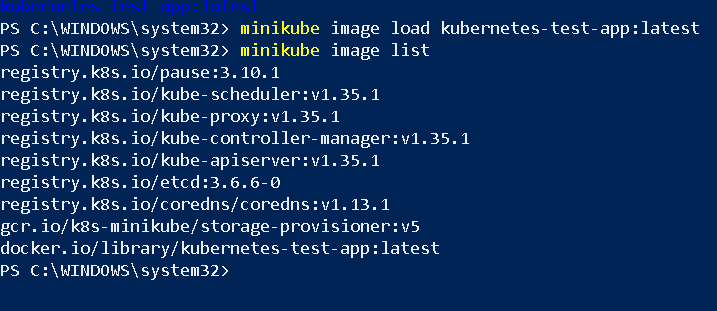

6. Deploy image to pods using deployment.yaml (kubernetes manifest file)
    - kubectl apply -f deployment.yaml (run from project directory)

7. To delete deployment
    - kubectl delete deployment kubernetes-test-app

8. Testing of deleting 1 pod to check if fault tolrence is active!!

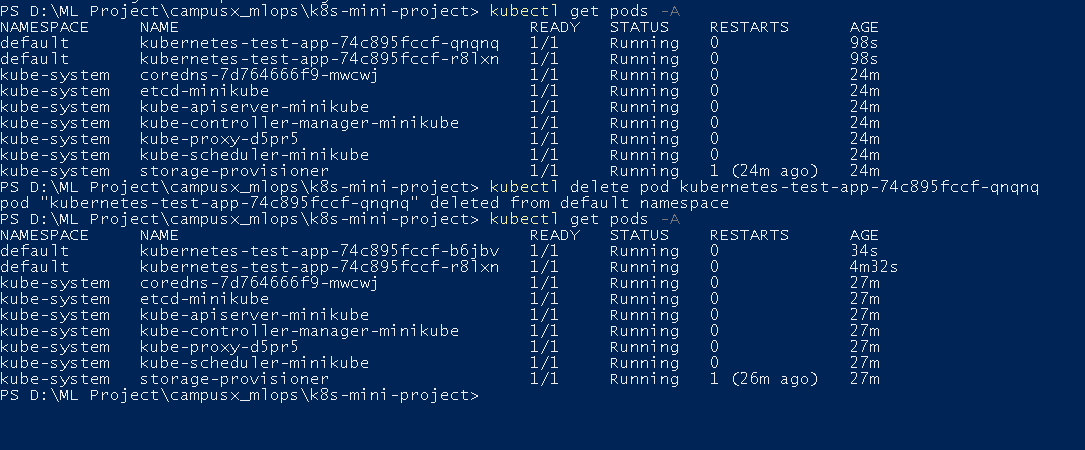

9. To view the dashboard of the kubernetes cluster
    - minikube dashboard
    - In production, we dont use this dashboard
    - In production, we use **Prometheous** & **Graffana**

10. kubectl logs -f <pod-id>

11. Load Testing with Postman
    - Use Postman to run performance tests:
        - Go to Collection > Runs > Performance > Run Performance Test.
        - Example: Fixed configuration with 10 users for 1 minute.

12. Stop the Minikube cluster:
    - minikube stop

# Prometheus & Grafana (Monitoring)

**Monolithic Architecture**  
- All ML workflow components run on a single server—simple to deploy but difficult to scale.

**Microservice Architecture**  
- Each ML workflow component runs as an independent service in separate Docker containers, orchestrated by Kubernetes. This enables scalability, fault isolation, and independent deployments.

**Why Monitoring Matters: The Uber Example**
- Uber's platform relies on multiple microservices working together:
- Rider matching
- Driver availability
- ETA calculation
- Payment processing
- If even one service experiences latency or fails, the user experience degrades immediately. Customers will switch to competitors—resulting in direct revenue loss.
- In a microservice ecosystem, real-time monitoring is very important, Every service must be continuously observed to ensure performance, availability, and reliability.

**What to Monitor**
1. Is the server running
2. Functioning as expected like data ingestion not able to connect to api or data columns are incorrect etc
3. Performing well like expecting output in 3sec but its taking 20sec or more : High latency
    - we can add an alert: If its taking more time then raise an alert or notification

**Monitoring vs Observability**
- Monitoring is the practice of collecting and tracking system metrics—CPU usage, memory, error rates, response times. It answers: "What is happening?"
- Observability goes deeper. It's the ability to understand why something is happening by analyzing system outputs (logs, metrics, traces). It answers: "Why is this happening?"
- Data collected for monitoring is called **Telemetry data**


**`Prometheus colects data & Grafana is used to visualize that data`**

## Prometheus-Grafana Sample Project On Kubernetes Cluster

1. create a sample flask app
2. start docker desktop
3. create dockerfile
4. build docker image: docker build -t flask-metrics-app:latest .
5. create manifest.yaml file (kubernetes config/setting file)
6. start cluster: (minikube delete --all) minikube start
7. add docker image into kubernetes (minikube cluster): minikube image load flask-metrics-app:latest
8. minikube image list
9. apply kube manifest file (from root dir of proj): kubectl apply -f flask-app.yaml
10. Now flask app is running from inside the kubernetes cluster in the pod, access it: minikube service flask-metrics-app --url (this will return a url where flask app is running)
11. Next, we need to give this url to prometheus to start tracking -- but for that we need to install and run it inside kubernetes cluster
    - Open new terminal
    - Install Prometheus Using Helm: Install helm - (winget install Helm.Helm / scoop install helm / choco install kubernetes-helm)
    - Validate if helm was installed properly - helm version
    - Add Prometheus to Helm repo: helm repo add prometheus-community https://prometheus-community.github.io/helm-charts
    - run: helm repo update
    - run: helm search repo prometheus
    - **Use helm to install Prometheus in minikube cluster**: helm install prometheus prometheus-community/prometheus --namespace monitoring --create-namespace
12. Access prometheus dashboard
    - list all services in monitoring namespace: kubectl get svc -n monitoring
    - expose promethues locally: kubectl port-forward -n monitoring svc/prometheus-server 9090:80
    - Now open localhost:9090 to access prometheus server

    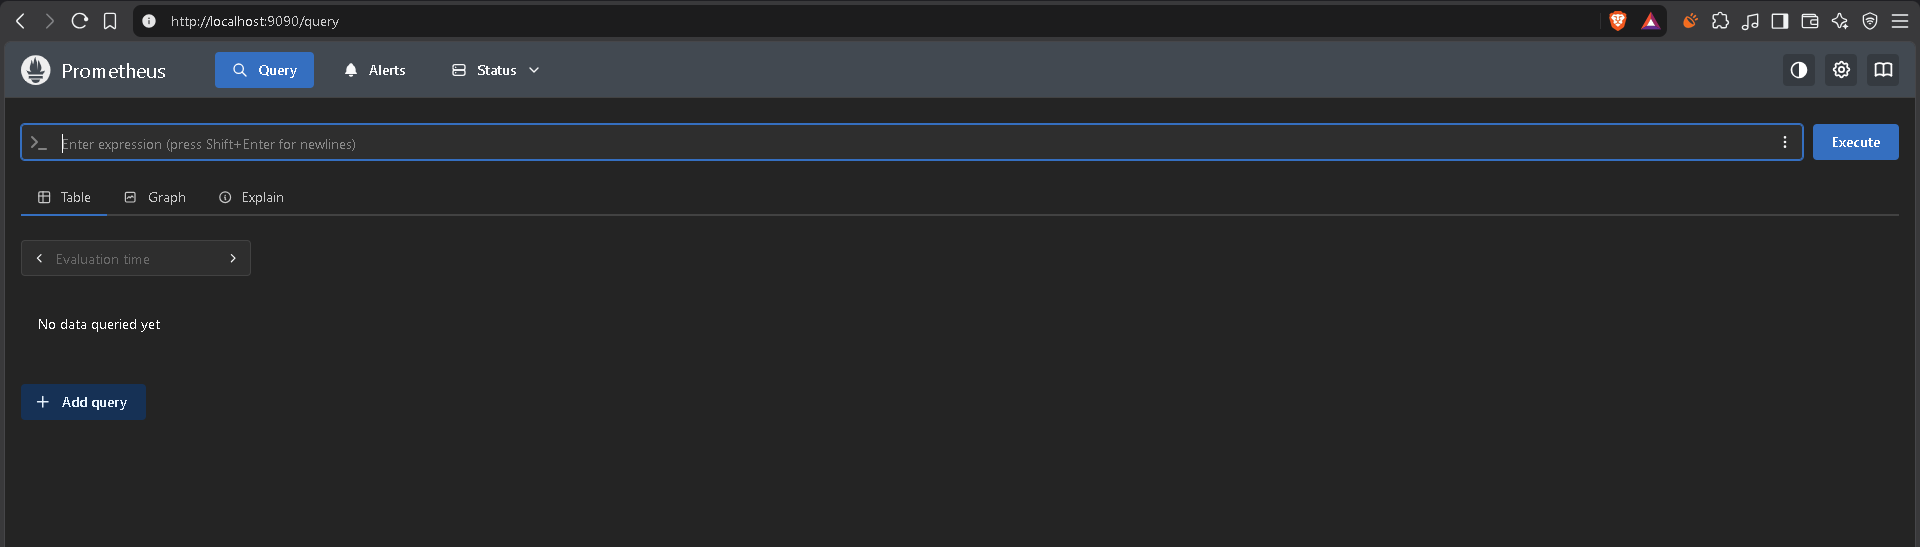

13. Configure prometheus to scrape flask app
    - get flask app service ip: (open new terminal) **kubectl get svc**
    - look for flask metrics app and note its cluster ip and port (flask-metrics-app   NodePort    10.97.141.225   <none>        5000:30409/TCP   11m)
    - update prometheus config map to add your flask app as  a scrape target: kubectl edit configmap prometheus-server -n monitoring (this will open notepad, be cautious)
    - look for scrape_configs section and add:

        `    scrape_configs:
        - job_name: 'flask-app'
            static_configs:
            - targets: ['10.107.61.186:5000']
        `
    - Now prometheus knows from which address it needs to access flask metrics
    - Just re-run prometheus server
        - kubectl get deploy -n monitoring
        - Restart the Deployment: kubectl rollout restart deployment prometheus-server -n monitoring
        - kubectl get pods -n monitoring (To check if prometheus is running)
        - again port forwarding to access: kubectl port-forward -n monitoring svc/prometheus-server 9091:80
        - check any metrics

        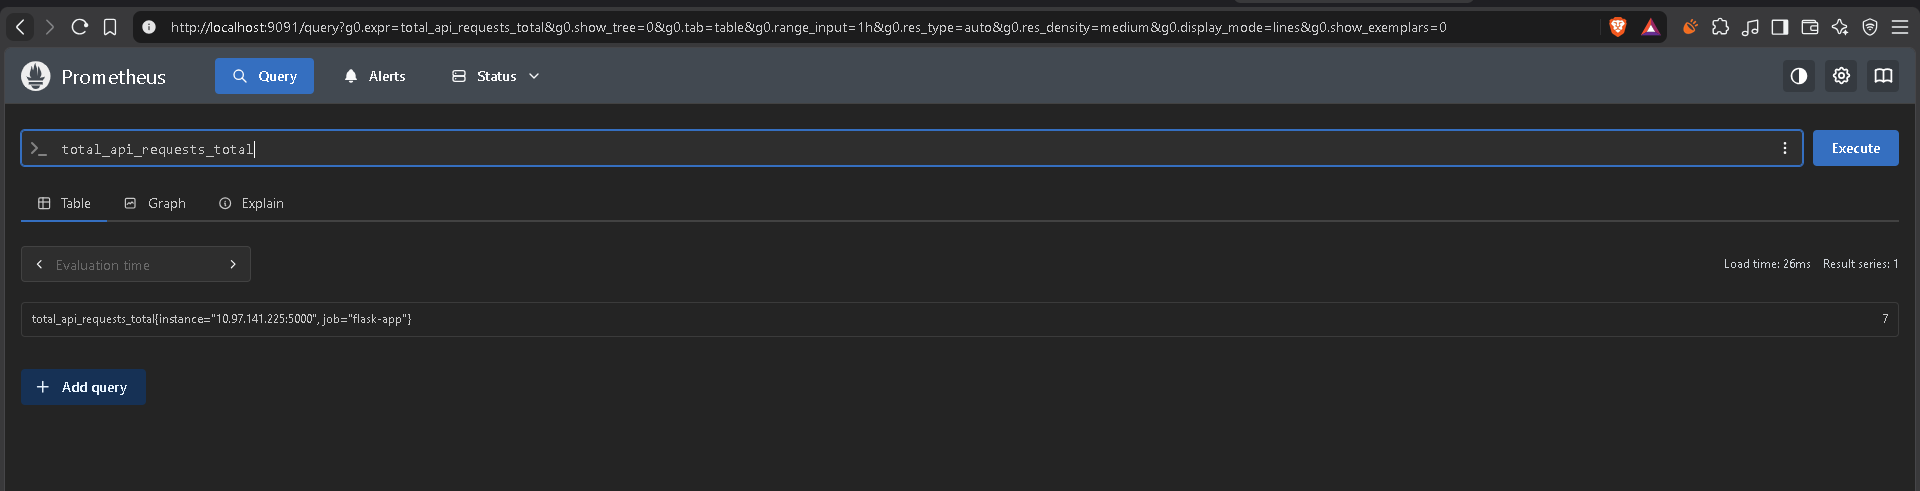


14. Install grafana on minikube cluster
    - run: helm repo add grafana https://grafana.github.io/helm-charts
    - run: helm repo update
    - Install Grafana in the Monitoring Namespace - helm install grafana grafana/grafana -n monitoring --create-namespace

15. Now we will do the settings to make Grafana accessible locally
    - Check Grafana Installation: kubectl get pods -n monitoring
    - Also verify grafana service also avialable: kubectl get svc -n monitoring  (you should see port: 80)
    - Do port forwarding(only for local testing): kubectl port-forward svc/grafana -n monitoring 3000:80
    - Access it from localhost:3000
    - Login to Grafana: [username: admin | Check default password: see below instruction]
    - **Bash** - kubectl get secret --namespace monitoring grafana -o jsonpath="{.data.admin-password}" | base64 --decode ; echo
        - Vi5TnajL8yX8MgNbm5BznaWbbwobjZbJAmUfKvcb
    - **Windowns Poershell** - kubectl get secret --namespace monitoring grafana -o jsonpath="{.data.admin-password}" [get the base64 code]
    -   [System.Text.Encoding]::UTF8.GetString([System.Convert]::FromBase64String("<You Code>"))

16. Add Prometheus as a Data Source
    - Once login to Grana, navigate to: Connection
     + Data Sources
     + Add Data Source
     + Prometheus
     + Since Prometheus is running inside the cluster, use its ClusterIP service URL: http://prometheus-server.monitoring.svc.cluster.local:80
     + Scroll down and click Save & Test.

# EKS Deployment

**Complete ML Workflow**

1. Setup project folder (src + experiments folder, github, dvc, s3 remote etc)
2. Data Cleaning, EDA, Transformations
3. Perform Experiments (Find out best algorithm & parameters) and push model to staging
4. Create DVC pipeline of best experiments
5. Log model to mode_registry
5. Perform tests on model and once cleared push to production stage of model registry
6. Create docker image of api using latest model in model_registry and push it to ECR, **Add metrics route also for monitoring in prometheus & grafana**
7. All above steps are done using CI/CD pipeline
8. CI/CD pipeline will pull the latest image in production on model_registry and deploy it to AWS EC2 CodeDeploy / ECS / EKS as per the requirement

1. Make sure below 3 things are avaiable on local pc
    - Verify AWS CLI: aws --version
    - Verify kubectl: kubectl version --client
    - Verify eksctl: eksctl version 
        - powershell -Command "$url='https://github.com/weaveworks/eksctl/releases/latest/download/eksctl_Windows_amd64.zip'; $zip=\"$env:TEMP\eksctl.zip\"; $dest=\"$env:TEMP\eksctl\"; Invoke-WebRequest -Uri $url -OutFile $zip; Expand-Archive -Path $zip -DestinationPath $dest -Force; Copy-Item \"$dest\eksctl.exe\" 'C:\Windows\System32\eksctl.exe' -Force; eksctl version"

2. Earlier in test project we created kubernetes cluster locally using minikube
    - Now since this is live deployment, We will create a kubernetes cluster on AWS platform
    - run: **eksctl create cluster --name flask-app-cluster --region us-east-1 --nodegroup-name flask-app-nodes --node-type t3.small --nodes 1 --nodes-min 1 --nodes-max 1 --managed**

3. Once cluster is created, eksctl will automatically update your kubectl config file. however you can verify and set it manually
    - aws eks --region us-east-1 update-kubeconfig --name flask-app-cluster
    - This ensures your kubectl is pointing to the correct cluster

4. Check EKS Cluster Configuration Ensure you can access your EKS cluster by running
    - aws eks list-clusters


5. Delete cluster(optional)
    - eksctl delete cluster --name flask-app-cluster --region us-east-1
    - Also, verify cluster deletion: eksctl get cluster --region us-east-1

6. Verify the cluster status
    - aws eks --region us-east-1 describe-cluster --name flask-app-cluster --query "cluster.status"


7. Check cluster connectivity:
    - kubectl get nodes

8. Check the namespaces:
    - kubectl get namespaces

9. Verify the deployment:
    - kubectl get pods
    - kubectl get svc

10. Deploy the app on EKS via CICD pipeline
    - edit ci.yaml

    ```
      - name: Set Up kubectl
        uses: azure/setup-kubectl@v3
        with:
          version: 'latest'
      
      - name: Update kubeconfig
        run: |
          aws eks update-kubeconfig --region us-east-1 --name flask-app-cluster

      - name: Create Kubernetes Secret
        run: |
          kubectl create secret generic capstone-secret \
            --from-literal=CAPSTONE_TEST=${{ secrets.CAPSTONE_TEST }} --dry-run=client -o yaml | kubectl apply -f -

      - name: Deploy to EKS
        run: |
          kubectl apply -f deployment.yaml
    ```

    - deployment.yaml

    ```
    apiVersion: apps/v1
    kind: Deployment
    metadata:
    name: flask-app
    labels:
        app: flask-app
    spec:
    replicas: 2
    selector:
        matchLabels:
        app: flask-app
    template:
        metadata:
        labels:
            app: flask-app
        spec:
        containers:
        - name: flask-app
            image: 020866158197.dkr.ecr.us-east-1.amazonaws.com/flask-app:latest
            ports:
            - containerPort: 5000
            resources:
            requests:
                memory: "256Mi"
                cpu: "250m"
            limits:
                memory: "512Mi"
                cpu: "1"
            env:
            - name: CAPSTONE_TEST
            valueFrom:
                secretKeyRef:
                name: capstone-secret
                key: CAPSTONE_TEST

    ---
    apiVersion: v1
    kind: Service
    metadata:
    name: flask-app-service
    spec:
    type: LoadBalancer
    selector:
        app: flask-app
    ports:
        - name: http
        protocol: TCP
        port: 5000
        targetPort: 5000
    ```


    - dockerfile

    ```
    CMD ["gunicorn", "--bind", "0.0.0.0:5000", "--timeout", "120", "app:app"]
    ```

    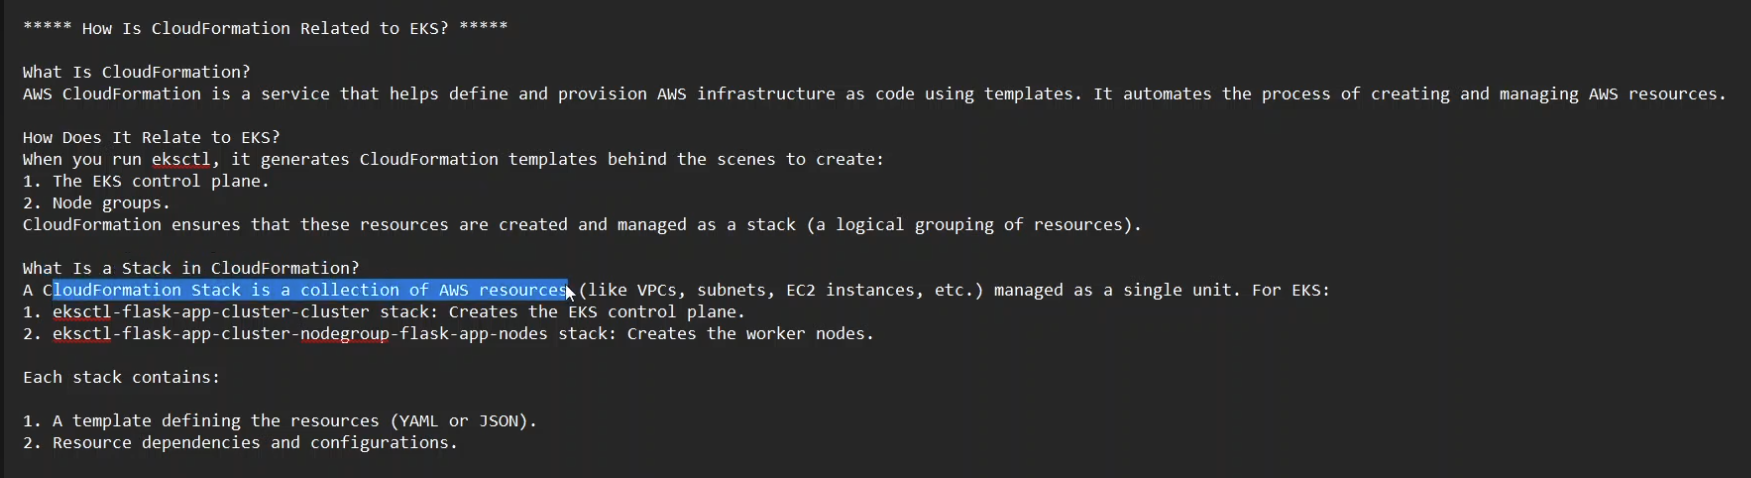

    - Also edit the security group for nodes (ec2 instances) and edit inbound rule for 5000 port


11. Push code to github to trigger CI/CD pipeline which will run dvc pipeline, push image to ecr, deploy the image on EKS
    - verify the status
    - kubectl get pods


12. Once Load Balancer service is up, get external IP
    - kubectl get svc flask-app-service
    - that IP is the url of the app deployed on EKS